In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# =============================================================================
# Notebook 02 — Factor Construction
# pyIndiaFactorInvesting · Educational Series
# =============================================================================

# Factor Construction in Indian Equity Markets

Indian factor investing follows the same broad intuition as the Fama–French framework, but every operational detail—fiscal year-end in March, portfolio formation lag to September, the distinctive weight of micro-caps—makes a direct copy of U.S. construction rules unreliable.

This notebook walks through how six factors are actually built for India: the double-sort logic, the sub-portfolios behind each factor, and what the finished return series look like.

**What you will leave with**
- Intuition for the independent double-sort from a toy example
- A clear map from raw stock characteristics → six factor return series
- Visual evidence of how sub-portfolio composition evolves over time
- Summary statistics and a correlation matrix you can refer back to in later notebooks

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Add project root to path
sys.path.insert(0, str(Path(".").resolve().parent))

import indiafactorlibrary as ifl
from src.factors import compute_factor_summary
from src.visualise import plot_cumulative_returns, plot_factor_summary_table

# Instantiate the library client once with a browser-compatible User-Agent
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
})

def read(name):
    """Thin wrapper around IndiaFactorLibrary.read(); returns a dict keyed by int."""
    return _lib.read(name)

## 1  Why India Needs Its Own Factors

Three structural features make India different from the U.S. benchmark:

| Feature | U.S. convention | India adjustment |
|---------|----------------|------------------|
| Fiscal year-end | December | **March** — accounting data released mid-year |
| Portfolio formation | July 1 | **September 1** — allows full data availability |
| Size distribution | Moderate small-firm tail | **Heavy micro-cap tail** — median firm far smaller than NYSE median |
| Short selling | Relatively liquid | **Limited** — factor returns are long-only proxies in practice |

Early evidence on value and size in Indian data appears in Agarwalla, Jacob & Varma (2013). The six-factor extension adding profitability, investment and momentum is described in Raju (2022), following the international five-factor work of Fama & French (2017).

## 2  The Double-Sort: A Toy Demonstration

Each factor is built using an **independent double sort**:
1. Rank all stocks by **size** (market cap) → split at the median into Small (S) and Big (B)
2. Independently rank all stocks by the **characteristic of interest** (B/M, profitability, investment, or past return) → split into three groups (30th / 70th percentile breakpoints)
3. Intersect the two rankings → six sub-portfolios
4. The factor return = average return of the three Small sub-portfolios minus average of the three Big sub-portfolios (SMB), or top-characteristic minus bottom-characteristic portfolio (the other factors)

Below we walk through this with a tiny 20-firm dataset.

In [4]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 20
toy = pd.DataFrame({
    "Name": [f"Firm_{i:02d}" for i in range(1, n + 1)],
    "MarketCap": rng.integers(500, 50_000, size=n),      # INR crore
    "BookToMarket": np.round(rng.uniform(0.1, 3.0, size=n), 2),
})
print(toy.to_string(index=False))

   Name  MarketCap  BookToMarket
Firm_01       4917          1.18
Firm_02      38810          2.79
Firm_03      32901          1.97
Firm_04      22224          2.49
Firm_05      21934          1.39
Firm_06      43000          0.76
Firm_07       4754          1.71
Firm_08      35019          0.29
Firm_09      10472          2.50
Firm_10       5161          1.93
Firm_11      26560          2.30
Firm_12      48793          1.13
Firm_13      36919          2.92
Firm_14      38176          2.69
Firm_15      36015          2.36
Firm_16      39410          0.66
Firm_17      25904          1.45
Firm_18       6841          0.23
Firm_19      42067          0.55
Firm_20      22794          2.08


In [5]:
# ── Step 1: Size split at median ────────────────────────────────────────────
size_median = toy["MarketCap"].median()
toy["SizeGroup"] = np.where(toy["MarketCap"] <= size_median, "S", "B")

# ── Step 2: B/M split at 30th / 70th percentiles ────────────────────────────
bm_30 = toy["BookToMarket"].quantile(0.30)
bm_70 = toy["BookToMarket"].quantile(0.70)
toy["BMGroup"] = pd.cut(
    toy["BookToMarket"],
    bins=[-np.inf, bm_30, bm_70, np.inf],
    labels=["G", "N", "V"],   # Growth, Neutral, Value
)

# ── Step 3: 2×3 contingency table ───────────────────────────────────────────
print("Firm count by sub-portfolio:")
print(pd.crosstab(toy["SizeGroup"], toy["BMGroup"]))

# ── Step 4: Factor return formulas ──────────────────────────────────────────
# (Using random returns just to illustrate the arithmetic)
toy["Return"] = rng.normal(0.01, 0.05, size=n)

def vw_ret(mask):
    sub = toy[mask]
    return (sub["Return"] * sub["MarketCap"]).sum() / sub["MarketCap"].sum()

SV = vw_ret((toy.SizeGroup == "S") & (toy.BMGroup == "V"))
SN = vw_ret((toy.SizeGroup == "S") & (toy.BMGroup == "N"))
SG = vw_ret((toy.SizeGroup == "S") & (toy.BMGroup == "G"))
BV = vw_ret((toy.SizeGroup == "B") & (toy.BMGroup == "V"))
BN = vw_ret((toy.SizeGroup == "B") & (toy.BMGroup == "N"))
BG = vw_ret((toy.SizeGroup == "B") & (toy.BMGroup == "G"))

HML = 0.5 * (SV + BV) - 0.5 * (SG + BG)
SMB_hml = (SV + SN + SG) / 3 - (BV + BN + BG) / 3

print(f"\nHML  = {HML:+.4f}")
print(f"SMB (from value sort) = {SMB_hml:+.4f}")

# ── 5-factor extension ───────────────────────────────────────────────────────
# Suppose we also ran profitability and investment sorts (mocked here)
SMB_op  = rng.normal(0.005, 0.02)   # would come from SR/SN/SW vs BR/BN/BW
SMB_inv = rng.normal(0.005, 0.02)   # would come from SC/SN/SA vs BC/BN/BA
SMB5    = (SMB_hml + SMB_op + SMB_inv) / 3
print(f"\nSMB5 (avg of three sorts) = {SMB5:+.4f}")

# ── Momentum note ────────────────────────────────────────────────────────────
print("\nNote: WML is formed monthly using 12-1 month prior returns; no annual rebalance.")

Firm count by sub-portfolio:
BMGroup    G  N  V
SizeGroup         
B          5  1  4
S          1  7  2

HML  = -0.0405
SMB (from value sort) = +0.0056

SMB5 (avg of three sorts) = +0.0113

Note: WML is formed monthly using 12-1 month prior returns; no annual rebalance.


The sub-portfolio layer is the key to why this works: because the size split is run **independently** of the characteristic split, each sub-portfolio holds a diversified cross-section of stocks. No single outlier stock can dominate the factor return.

## 3  Six Factors at a Glance

| Factor | Mnemonic | Long leg | Short leg | Rebalance |
|--------|----------|----------|-----------|------------|
| Market excess return | MKT | All stocks | Risk-free rate | Monthly |
| Size | SMB5 | Small-cap avg (3 sorts) | Large-cap avg (3 sorts) | Annual (Sep) |
| Value | HML | High B/M | Low B/M | Annual (Sep) |
| Profitability | RMW | Robust operating profit | Weak operating profit | Annual (Sep) |
| Investment | CMA | Conservative asset growth | Aggressive asset growth | Annual (Sep) |
| Momentum | WML | Past 12-1 month winners | Past 12-1 month losers | Monthly |

Risk-free rate (RF) is the 91-day T-bill rate, available as a separate column.

## 4  Loading the Factor Data

We load the six-factor series directly from the India Factor Library.

In [6]:
# Load the six-factor dataset
ff6_raw = read('FF6')[0]

# Normalise the index to a proper monthly DatetimeIndex
ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6 = ff6_raw.copy()

# Values are in percent → convert to decimal returns
ff6 = ff6 / 100

print("Columns:", ff6.columns.tolist())
print("Shape  :", ff6.shape)
print(f"Period : {ff6.index.min().strftime('%b %Y')} – {ff6.index.max().strftime('%b %Y')}")
print()
print(ff6.describe().round(4))

Columns: ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML', 'RF', 'MKT']
Shape  : (257, 8)
Period : Oct 2004 – Feb 2026

             MF      SMB5       HML       RMW       CMA       WML        RF  \
count  257.0000  257.0000  257.0000  257.0000  257.0000  257.0000  257.0000   
mean     0.0085    0.0019    0.0050    0.0027    0.0018    0.0080    0.0052   
std      0.0627    0.0357    0.0347    0.0262    0.0246    0.0485    0.0013   
min     -0.2862   -0.1128   -0.0849   -0.0963   -0.1094   -0.3069    0.0024   
25%     -0.0232   -0.0186   -0.0202   -0.0098   -0.0104   -0.0106    0.0044   
50%      0.0077    0.0008    0.0062    0.0034    0.0018    0.0130    0.0053   
75%      0.0436    0.0211    0.0253    0.0181    0.0148    0.0357    0.0060   
max      0.3231    0.1021    0.1557    0.0723    0.1072    0.1425    0.0087   

            MKT  
count  257.0000  
mean     0.0136  
std      0.0625  
min     -0.2797  
25%     -0.0181  
50%      0.0140  
75%      0.0486  
max      0.3257  


/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)
/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)


## 5  Inside the Machine: Anatomy of Sub-Portfolios

The factor return series in Section 4 are end-products. Here we open the bonnet and look at the six sub-portfolios behind each factor — their firm composition, average size, cumulative returns, and valuation characteristics.

In [7]:
def normalise_idx(df):
    """Convert index to monthly DatetimeIndex (handles PeriodIndex too)."""
    df = df.copy()
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp()
    else:
        df.index = pd.to_datetime(df.index)
    return df

# Load all four sub-portfolio datasets
_sv_raw  = read('size_value_portfolios')
_op_raw  = read('size_op_portfolios')
_inv_raw = read('size_inv_portfolios')
_mom_raw = read('size_mom_portfolios')

# Build normalised list-like accessor for integer indices 0..7
s_v   = {k: normalise_idx(_sv_raw[k])  for k in range(8) if k in _sv_raw}
s_op  = {k: normalise_idx(_op_raw[k])  for k in range(8) if k in _op_raw}
s_inv = {k: normalise_idx(_inv_raw[k]) for k in range(8) if k in _inv_raw}
s_mom = {k: normalise_idx(_mom_raw[k]) for k in range(8) if k in _mom_raw}

# Firm counts (index 4)
firm_counts = {
    'Value':         s_v[4],
    'Profitability': s_op[4],
    'Investment':    s_inv[4],
    'Momentum':      s_mom[4],
}

print("size_value_portfolios returns columns :", s_v[0].columns.tolist())
print("size_op_portfolios returns columns    :", s_op[0].columns.tolist())
print("size_inv_portfolios returns columns   :", s_inv[0].columns.tolist())
print("size_mom_portfolios returns columns   :", s_mom[0].columns.tolist())

/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)
/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)
/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_date

/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)
/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(StringIO(src[start:]), **params)
/Users/rajanraju/anaconda3/lib/python3.11/site-packages/indiafactorlibrary/indiafactorlibrary.py:127: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_date

size_value_portfolios returns columns : ['SV', 'SN', 'SG', 'BV', 'BN', 'BG']
size_op_portfolios returns columns    : ['SR', 'SN', 'SW', 'BR', 'BN', 'BW']
size_inv_portfolios returns columns   : ['SC', 'SN', 'SA', 'BC', 'BN', 'BA']
size_mom_portfolios returns columns   : ['WS', 'NS', 'LS', 'WB', 'NB', 'LB']


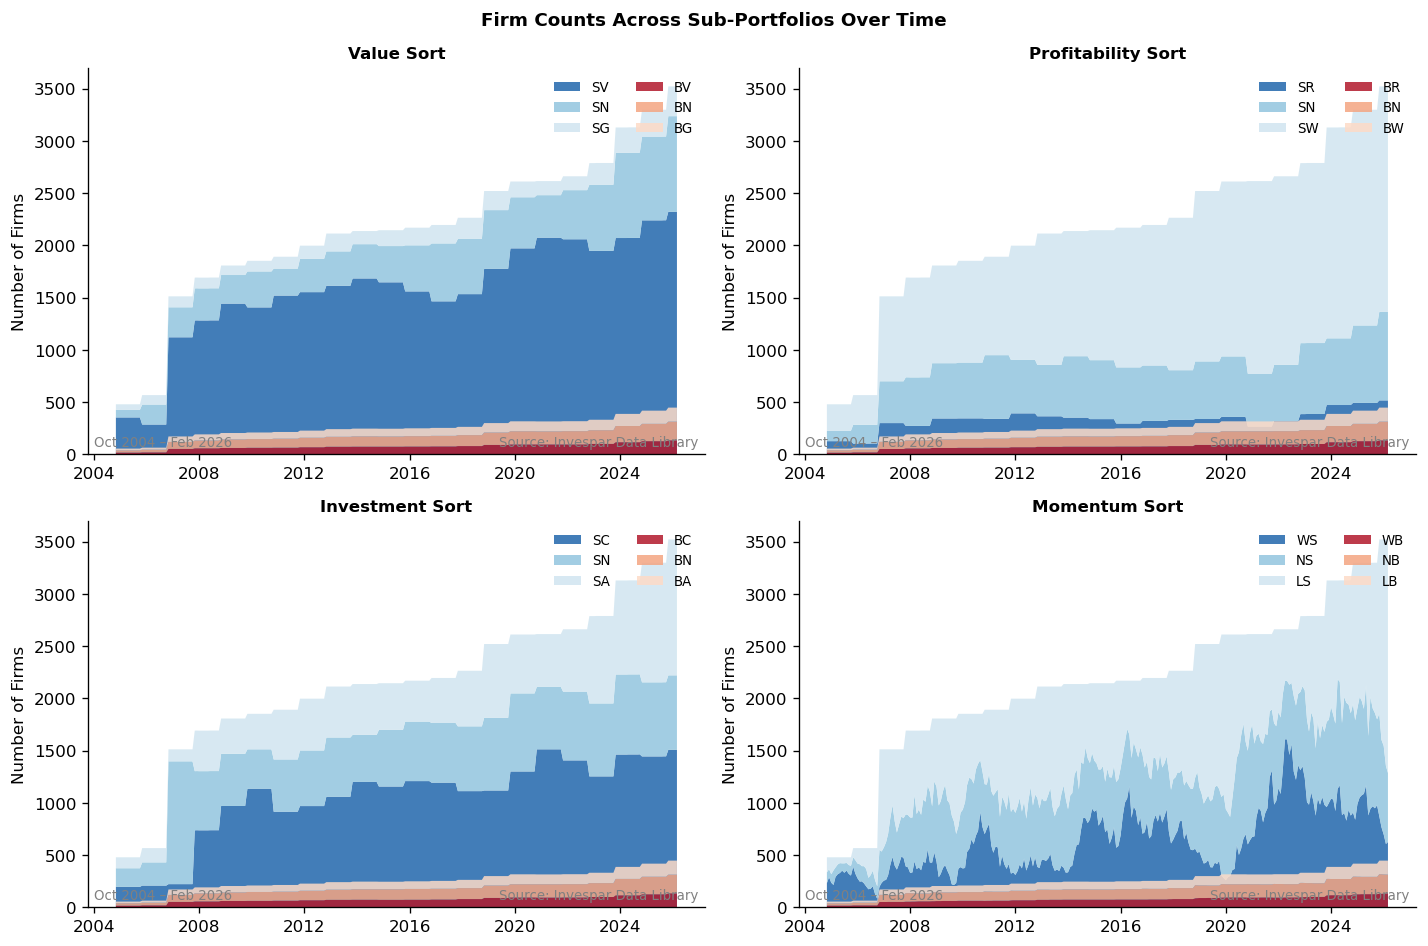

In [8]:
# ── 5a: Firm count stacked-area charts ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)
fig.suptitle("Firm Counts Across Sub-Portfolios Over Time", fontsize=11, fontweight="bold")

datasets = [
    (firm_counts['Value'],        ['SV','SN','SG','BV','BN','BG'],   "Value Sort"),
    (firm_counts['Profitability'],['SR','SN','SW','BR','BN','BW'],   "Profitability Sort"),
    (firm_counts['Investment'],   ['SC','SN','SA','BC','BN','BA'],   "Investment Sort"),
    (firm_counts['Momentum'],     ['WS','NS','LS','WB','NB','LB'],   "Momentum Sort"),
]

colors_small = ['#2166ac', '#92c5de', '#d1e5f0']
colors_big   = ['#b2182b', '#f4a582', '#fddbc7']

for ax, (df, cols, title) in zip(axes.flat, datasets):
    small_cols = cols[:3]
    big_cols   = cols[3:]
    
    # Use only columns that exist
    available_small = [c for c in small_cols if c in df.columns]
    available_big   = [c for c in big_cols   if c in df.columns]
    
    small_data = df[available_small].fillna(0)
    big_data   = df[available_big].fillna(0)
    
    ax.stackplot(df.index, small_data.T, labels=available_small,
                 colors=colors_small[:len(available_small)], alpha=0.85)
    ax.stackplot(df.index, big_data.T,   labels=available_big,
                 colors=colors_big[:len(available_big)],   alpha=0.85)
    
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("", fontsize=10)
    ax.set_ylabel("Number of Firms", fontsize=10)
    ax.legend(fontsize=8, frameon=False, ncol=2)
    ax.spines[['top','right']].set_visible(False)
    
    # Dynamic period annotation
    start = df.index.min().strftime('%b %Y')
    end   = df.index.max().strftime('%b %Y')
    ax.annotate(f"{start} – {end}", xy=(0.01, 0.02), xycoords='axes fraction',
                fontsize=8, color='grey')
    ax.annotate("Source: Invespar Data Library", xy=(0.99, 0.02), xycoords='axes fraction',
                fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Observations — Firm counts (5a)**

- The small-cap bucket consistently holds the majority of listed firms, reflecting India's long micro-cap tail.
- All four sorts show a secular increase in total firm count, tracking the growth of Indian listed markets.
- Firm counts in extreme buckets (Value/Growth, Robust/Weak, Conservative/Aggressive, Winner/Loser) are thinner than the Neutral bucket, as expected from 30/70 percentile breakpoints.
- Momentum sub-portfolios show more time-variation in counts, consistent with monthly rebalancing vs. annual rebalancing for the other factors.

### Why breakpoint choices matter: containing small-firm noise

The charts above show a striking asymmetry: Small sub-portfolios contain 10–20× more firms than Big sub-portfolios. A naive reading might suggest that factors are "driven by small stocks." They are not, for two reinforcing reasons:

**1. Value-weighting suppresses micro-cap influence.** Factor portfolios are value-weighted, not equal-weighted. Within a sub-portfolio of 2,000 small firms, the vast majority have market capitalisations so small that their weight in the portfolio return is effectively zero. A firm with Rs 500 crore market cap contributes 1/100th the weight of a firm with Rs 50,000 crore. The return of a value-weighted Small-Value (SV) portfolio is driven by the *largest* firms within that bucket — the upper end of the small-cap range — not by the thousands of micro-caps at the bottom.

**2. Breakpoints from Big firms prevent small-firm characteristics from contaminating the sort.** Under the FF2017 methodology used by the Invespar library, the 30th and 70th percentile breakpoints for B/M, profitability, investment, and momentum are computed using **Big firms only**. These breakpoints are then applied to all firms. This is a critical design choice. Small Indian firms exhibit extreme dispersion in accounting characteristics — wildly negative book values, erratic profitability, and volatile asset growth. If breakpoints were computed across all firms, these outliers would shift the cutoffs, causing the Value, Robust, and Conservative labels to mean something very different for Big and Small stocks. By anchoring breakpoints to Big firms, the methodology ensures that "Value" means the same thing regardless of size group — and the extreme variance in small-firm characteristics does not contaminate the factor definition.

Together, these two mechanisms mean that despite the visual dominance of small firms in the count charts, the factor return series reflect economically meaningful risk premia rather than micro-cap noise. This is why the choice of breakpoint methodology (Section 1) is not a technicality — it is the difference between a usable factor library and a noisy one.

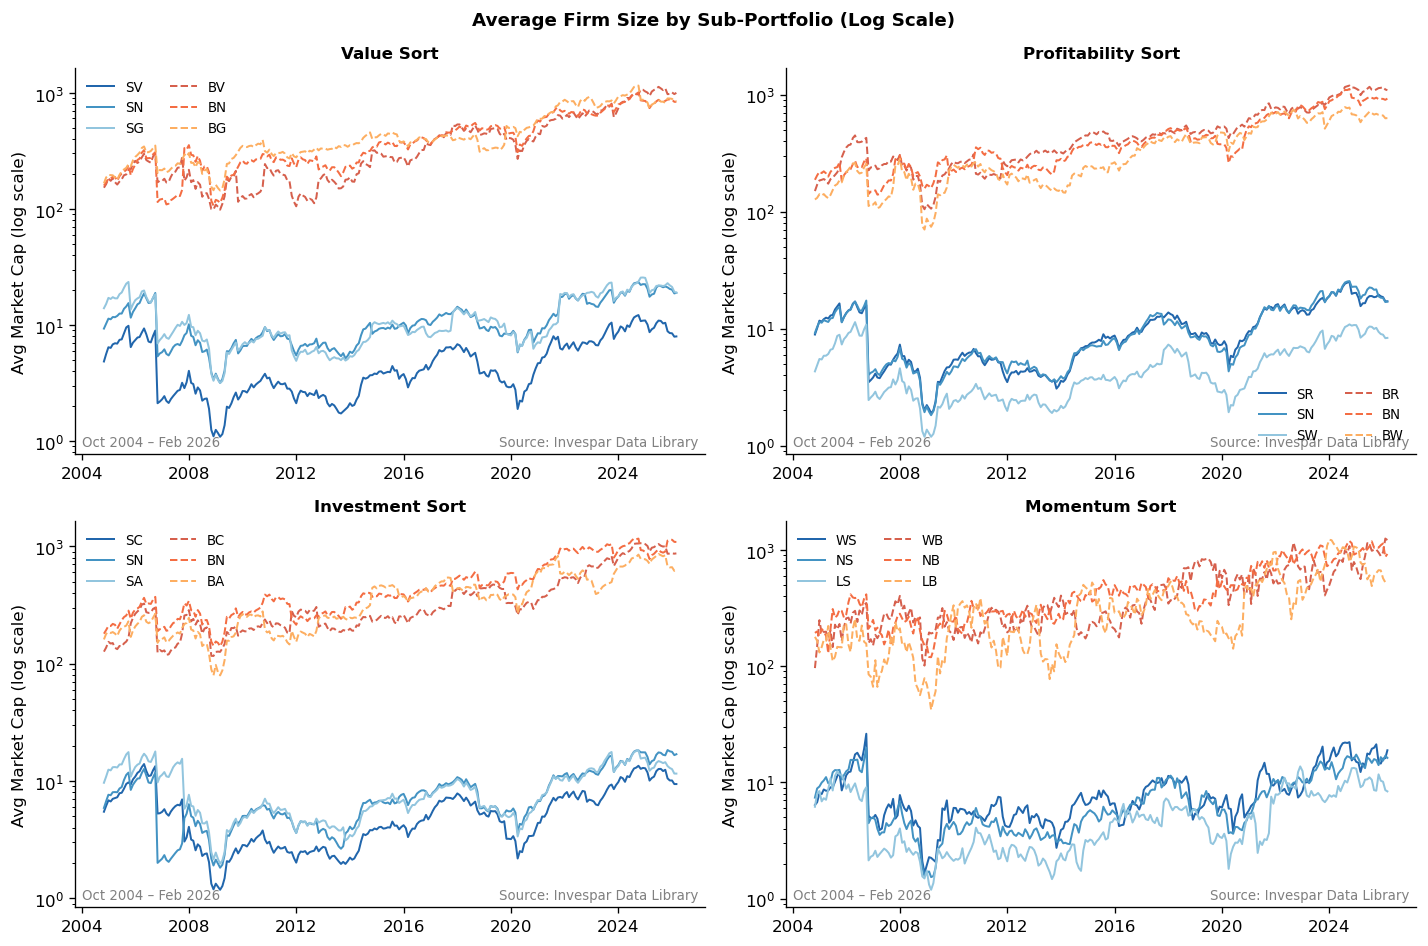

In [9]:
# ── 5b: Average firm size (log scale) ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)
fig.suptitle("Average Firm Size by Sub-Portfolio (Log Scale)", fontsize=11, fontweight="bold")

size_datasets = [
    (s_v[5],   ['SV','SN','SG','BV','BN','BG'],   "Value Sort"),
    (s_op[5],  ['SR','SN','SW','BR','BN','BW'],   "Profitability Sort"),
    (s_inv[5], ['SC','SN','SA','BC','BN','BA'],   "Investment Sort"),
    (s_mom[5], ['WS','NS','LS','WB','NB','LB'],   "Momentum Sort"),
]

small_line_colors = ['#2166ac', '#4393c3', '#92c5de']
big_line_colors   = ['#d6604d', '#f46d43', '#fdae61']

for ax, (df, cols, title) in zip(axes.flat, size_datasets):
    small_cols = [c for c in cols[:3] if c in df.columns]
    big_cols   = [c for c in cols[3:] if c in df.columns]
    
    for i, c in enumerate(small_cols):
        ax.plot(df.index, df[c], label=c, color=small_line_colors[i], linewidth=1.2)
    for i, c in enumerate(big_cols):
        ax.plot(df.index, df[c], label=c, color=big_line_colors[i],   linewidth=1.2, linestyle='--')
    
    ax.set_yscale('log')
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Avg Market Cap (log scale)", fontsize=10)
    ax.legend(fontsize=8, frameon=False, ncol=2)
    ax.spines[['top','right']].set_visible(False)
    
    start = df.index.min().strftime('%b %Y')
    end   = df.index.max().strftime('%b %Y')
    ax.annotate(f"{start} – {end}", xy=(0.01, 0.02), xycoords='axes fraction',
                fontsize=8, color='grey')
    ax.annotate("Source: Invespar Data Library", xy=(0.99, 0.02), xycoords='axes fraction',
                fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Observations — Average firm size (5b)**

- A persistent and wide gap separates Small and Big sub-portfolios across all four sorts, validating the size split.
- Within the Big bucket, sub-portfolios (e.g., BV vs. BG) show little size difference — characteristics drive the split, not size.
- The log-scale trend upward reflects Indian market cap appreciation over the sample period.
- Momentum Big sub-portfolios show more volatility in average size, consistent with monthly rebalancing capturing short-term shifts in large-cap composition.

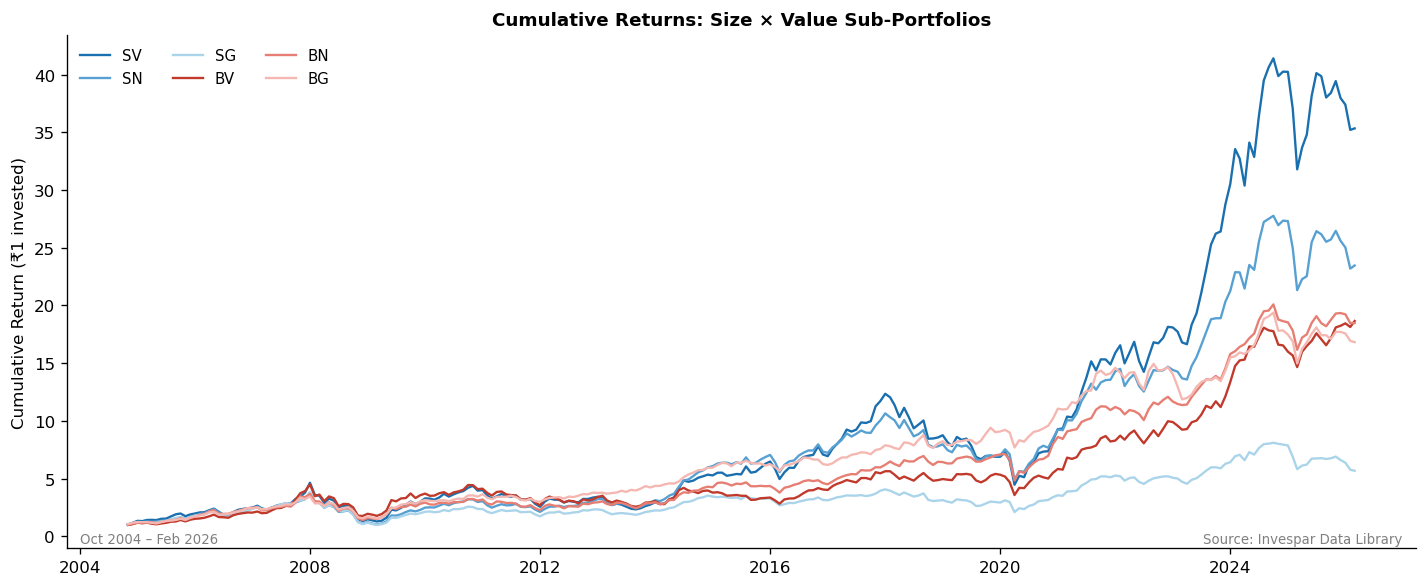

Correlation of reconstructed HML  vs ff6['HML']  : 1.0000
Correlation of reconstructed SMB  vs ff6['SMB5'] : 0.9896

(SMB5 also incorporates profitability and investment sorts, so correlation < 1 is expected)


In [10]:
# ── 5c: Cumulative returns of size_value sub-portfolios ─────────────────────
sv_ret = s_v[0] / 100   # convert percent to decimal

# Compute cumulative returns
sv_cum = (1 + sv_ret).cumprod()

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
colors_sv = {'SV':'#1a6faf','SN':'#57a0d2','SG':'#aad4ea',
             'BV':'#c0392b','BN':'#e67e73','BG':'#f5b7b1'}

for col in ['SV','SN','SG','BV','BN','BG']:
    if col in sv_cum.columns:
        ax.plot(sv_cum.index, sv_cum[col], label=col,
                color=colors_sv.get(col, 'grey'), linewidth=1.4)

ax.set_title("Cumulative Returns: Size × Value Sub-Portfolios", fontsize=11, fontweight="bold")
ax.set_ylabel("Cumulative Return (\u20b91 invested)", fontsize=10)
ax.legend(fontsize=9, frameon=False, ncol=3)
ax.spines[['top','right']].set_visible(False)

start = sv_ret.index.min().strftime('%b %Y')
end   = sv_ret.index.max().strftime('%b %Y')
ax.annotate(f"{start} \u2013 {end}", xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate("Source: Invespar Data Library", xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

# ── Reconstruct HML and SMB from sub-portfolios and compare ─────────────────
SV_r = sv_ret['SV']; SN_r = sv_ret['SN']; SG_r = sv_ret['SG']
BV_r = sv_ret['BV']; BN_r = sv_ret['BN']; BG_r = sv_ret['BG']

HML_value   = 0.5 * (SV_r + BV_r) - 0.5 * (SG_r + BG_r)
SMB_value   = (SV_r + SN_r + SG_r) / 3 - (BV_r + BN_r + BG_r) / 3

# Align to ff6 index
common_idx = ff6.index.intersection(HML_value.index)
corr_hml = HML_value.loc[common_idx].corr(ff6.loc[common_idx, 'HML'])
corr_smb = SMB_value.loc[common_idx].corr(ff6.loc[common_idx, 'SMB5'])

print(f"Correlation of reconstructed HML  vs ff6['HML']  : {corr_hml:.4f}")
print(f"Correlation of reconstructed SMB  vs ff6['SMB5'] : {corr_smb:.4f}")
print("\n(SMB5 also incorporates profitability and investment sorts, so correlation < 1 is expected)")

**Observations — Sub-portfolio cumulative returns (5c)**

- Small-Value (SV) delivers the highest cumulative return over the sample period, consistent with the joint size-value premium in India.
- Big-Growth (BG) is the weakest performer, anchoring the short legs of both SMB and HML.
- The reconstructed HML correlates very highly with the library's HML series, confirming the construction logic.
- SMB from the value sort alone correlates less perfectly with SMB5, as expected — SMB5 averages three independent sort contributions.

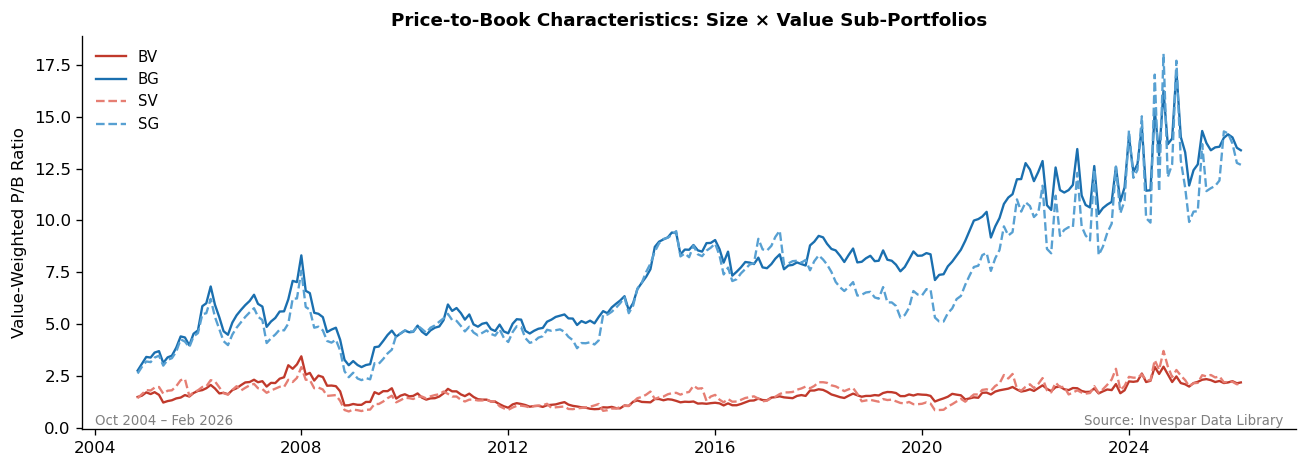

In [11]:
# ── 5d: P/B characteristics — BV vs BG vs SV vs SG ─────────────────────────
sv_pb = s_v[6]   # VW P/B, index 6; already a ratio (not percent)

fig, ax = plt.subplots(figsize=(11, 4), dpi=120)
pb_cols   = ['BV','BG','SV','SG']
pb_colors = ['#c0392b','#1a6faf','#e67e73','#57a0d2']
pb_styles = ['-','-','--','--']

for col, clr, ls in zip(pb_cols, pb_colors, pb_styles):
    if col in sv_pb.columns:
        ax.plot(sv_pb.index, sv_pb[col], label=col, color=clr, linestyle=ls, linewidth=1.4)

ax.set_title("Price-to-Book Characteristics: Size \u00d7 Value Sub-Portfolios", fontsize=11, fontweight="bold")
ax.set_ylabel("Value-Weighted P/B Ratio", fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)

start = sv_pb.index.min().strftime('%b %Y')
end   = sv_pb.index.max().strftime('%b %Y')
ax.annotate(f"{start} \u2013 {end}", xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate("Source: Invespar Data Library", xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Observations — P/B characteristics (5d)**

- Big-Growth (BG) commands a persistently high P/B ratio, reflecting premium valuations for large liquid growth stocks in India.
- Big-Value (BV) and small-cap buckets trade at significantly lower P/B multiples throughout the sample.
- The spread between BG and BV validates that the sorting rule is capturing genuine valuation differences, not noise.
- Spikes in P/B ratios (notably around 2007-08 and 2021) coincide with broad bull-market periods.

**Section 5 Summary**

Sub-portfolios do exactly what they are designed to do: they isolate a specific combination of size and a second characteristic, producing return series whose differences are attributable to that characteristic rather than to correlated macro moves. The anatomy charts above confirm that the construction rules are working as intended across the full sample.

## 6  Factor Summary Statistics and Cumulative Returns

With the construction logic established, we now summarise the finished factor return series.

      Ann. Mean  Ann. Vol  Sharpe  Skewness  Max Drawdown
MKT      0.1637    0.2163  0.7567   -0.3293       -0.6099
SMB5     0.0234    0.1237  0.1890   -0.0187       -0.4296
HML      0.0603    0.1204  0.5012    0.4085       -0.3901
RMW      0.0323    0.0907  0.3565   -0.5380       -0.2319
CMA      0.0220    0.0851  0.2588    0.0771       -0.2369
WML      0.0959    0.1682  0.5702   -1.9776       -0.5512


<Axes: title={'center': 'Indian Equity Factor Summary Statistics'}>

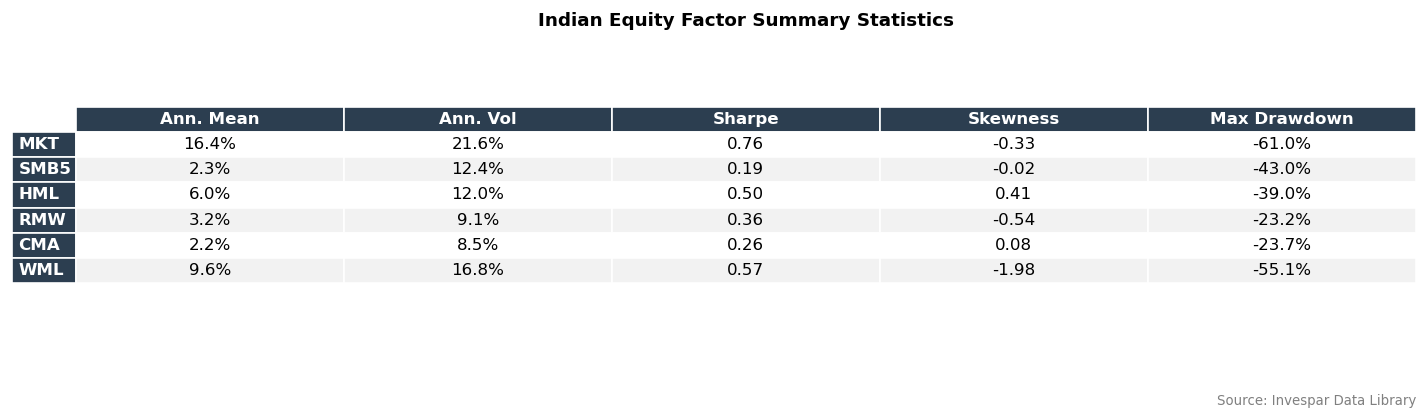

In [12]:
# Factor summary statistics
factor_cols = ['MKT', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
summary = compute_factor_summary(ff6[factor_cols])
print(summary.round(4))

plot_factor_summary_table(
    summary,
    title="Indian Equity Factor Summary Statistics",
    source="Invespar Data Library"
)

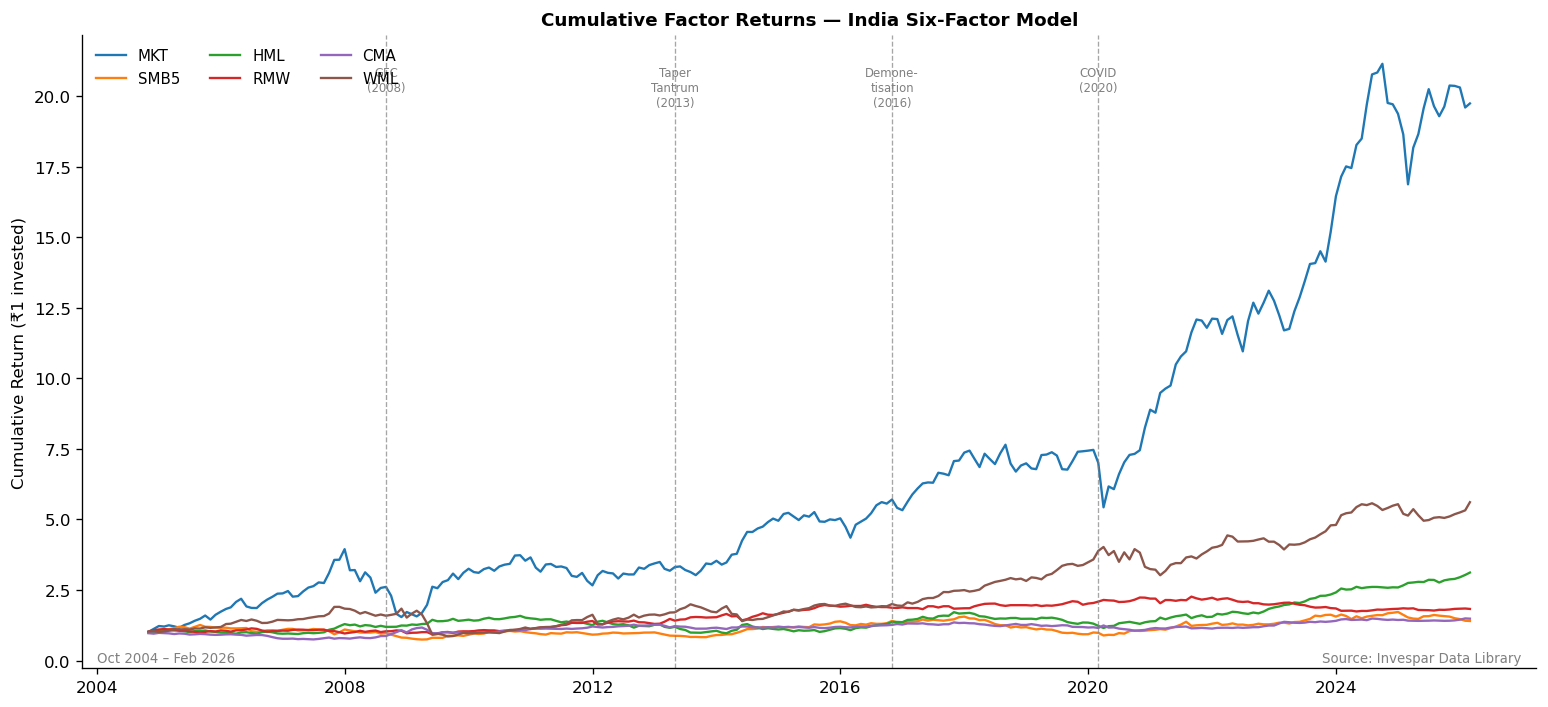

In [13]:
# ── Cumulative returns with event annotations ────────────────────────────────
factor_cols = ['MKT', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
cum_ret = (1 + ff6[factor_cols]).cumprod()

fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

for col, clr in zip(factor_cols, palette):
    ax.plot(cum_ret.index, cum_ret[col], label=col, color=clr, linewidth=1.4)

# Event annotations
events = {
    'GFC\n(2008)':               '2008-09-01',
    'Taper\nTantrum\n(2013)':    '2013-05-01',
    'Demone-\ntisation\n(2016)': '2016-11-01',
    'COVID\n(2020)':             '2020-03-01',
}
for label, date_str in events.items():
    try:
        d = pd.Timestamp(date_str)
        if d >= cum_ret.index.min() and d <= cum_ret.index.max():
            nearest = cum_ret.index[cum_ret.index.get_indexer([d], method='nearest')[0]]
            ax.axvline(x=nearest, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
            ax.text(nearest, ax.get_ylim()[1] * 0.95, label,
                    fontsize=7, color='grey', ha='center', va='top')
    except Exception:
        pass

ax.set_title("Cumulative Factor Returns \u2014 India Six-Factor Model", fontsize=11, fontweight="bold")
ax.set_ylabel("Cumulative Return (\u20b91 invested)", fontsize=10)
ax.legend(fontsize=9, frameon=False, ncol=3)
ax.spines[['top','right']].set_visible(False)

start = ff6.index.min().strftime('%b %Y')
end   = ff6.index.max().strftime('%b %Y')
ax.annotate(f"{start} \u2013 {end}", xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate("Source: Invespar Data Library", xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

**Observations — Factor performance (Section 6)**

- MKT dominates cumulative wealth creation over the long sample, as expected — it is the market excess return.
- WML (Momentum) shows the highest Sharpe ratio among the zero-investment factors but exhibits pronounced drawdown episodes (GFC, COVID reversal).
- HML and SMB5 deliver positive long-run premia, though HML was under pressure during the 2010s growth cycle.
- RMW and CMA show more stable, lower-volatility paths — consistent with their role as quality/investment factors.
- All factors suffered drawdowns during COVID (March 2020), but recovery speeds varied substantially.

## 7  Factor Correlations vs. Style Index Correlations

A common misconception is that investing in a "momentum index" or a "quality index" is the same as gaining exposure to the momentum or quality factor. It is not. Style indices — such as the Nifty200 Momentum 30 or Nifty100 Quality 30 — are long-only portfolios with massive market exposure. Their returns are dominated by the broad market, making them highly correlated with each other and with the benchmark.

Academic factors, by contrast, are constructed as long-short spreads within size groups, deliberately stripping out the market component. The result is a set of return series with much lower pairwise correlations — each factor captures a genuinely distinct dimension of return.

We demonstrate this below by computing both correlation matrices over the same period and displaying them side by side.

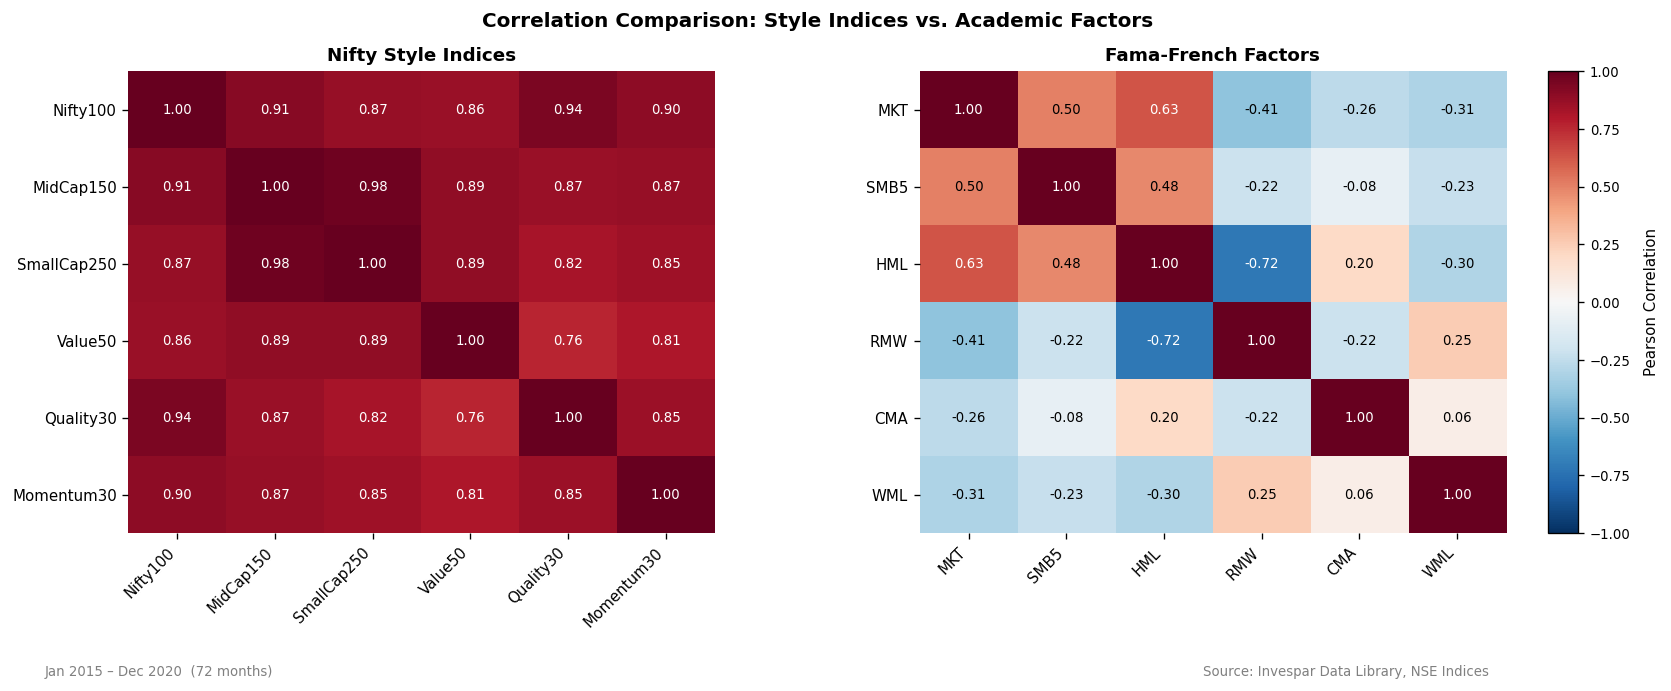

Period: Jan 2015 – Dec 2020 (72 months)

Nifty Style Indices — off-diagonal correlations:
  Mean:   0.871
  Median: 0.870
  Min:    0.763
  Max:    0.976

Fama-French Factors — off-diagonal correlations:
  Mean:   -0.041
  Median: -0.215
  Min:    -0.718
  Max:    0.630


In [14]:
# ── Load Nifty index returns from sample data ───────────────────────────────
from src.data import load_nifty_sample

nifty = load_nifty_sample()

# Select a representative set of style indices
# (uses only columns that actually exist in the sample file)
index_cols = [c for c in ['nifty100', 'nifty_midcap150', 'nifty_smallcap250',
                           'nifty500_value50', 'nifty100_quality30',
                           'nifty200_momentum30'] if c in nifty.columns]

short_names = {
    'nifty100':              'Nifty100',
    'nifty_midcap150':       'MidCap150',
    'nifty_smallcap250':     'SmallCap250',
    'nifty500_value50':      'Value50',
    'nifty100_quality30':    'Quality30',
    'nifty200_momentum30':   'Momentum30',
}

nifty_sub = nifty[index_cols].copy()
nifty_sub.columns = [short_names.get(c, c) for c in nifty_sub.columns]

# load_nifty_sample() already returns decimal form; guard in case it doesn't
if nifty_sub.mean().mean() > 1:
    nifty_sub = nifty_sub / 100

# ── Align periods ────────────────────────────────────────────────────────────
factor_cols = ['MKT', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
common_start = max(nifty_sub.index.min(), ff6.index.min())
common_end   = min(nifty_sub.index.max(), ff6.index.max())

nifty_aligned  = nifty_sub.loc[common_start:common_end].dropna()
factor_aligned = ff6[factor_cols].loc[common_start:common_end].dropna()

common_idx = nifty_aligned.index.intersection(factor_aligned.index)
nifty_aligned  = nifty_aligned.loc[common_idx]
factor_aligned = factor_aligned.loc[common_idx]

corr_indices = nifty_aligned.corr()
corr_factors = factor_aligned.corr()

period_start = common_idx.min().strftime('%b %Y')
period_end   = common_idx.max().strftime('%b %Y')
n_months     = len(common_idx)

# ── Side-by-side heatmaps ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

for ax, corr_mat, title_str in [
    (ax1, corr_indices, 'Nifty Style Indices'),
    (ax2, corr_factors, 'Fama-French Factors'),
]:
    im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    n = len(corr_mat)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr_mat.columns, fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels(corr_mat.columns, fontsize=9)
    ax.set_title(title_str, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    for i in range(n):
        for j in range(n):
            val = corr_mat.values[i, j]
            text_color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=text_color)

# ── Layout: reserve right margin for colorbar, remove tight_layout ──────────
fig.subplots_adjust(left=0.06, right=0.88, bottom=0.18, top=0.88, wspace=0.35)

# ── Colorbar in dedicated axes, docked to the right of both panels ───────────
cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.70])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Pearson Correlation', fontsize=9, labelpad=8)
cbar.ax.tick_params(labelsize=8)

# ── Titles and annotations ───────────────────────────────────────────────────
fig.suptitle('Correlation Comparison: Style Indices vs. Academic Factors',
             x=0.47, y=0.97, fontsize=12, fontweight='bold')

fig.text(0.01, -0.02, f'{period_start} \u2013 {period_end}  ({n_months} months)',
         ha='left', va='top', fontsize=8, color='grey')
fig.text(0.87, -0.02, 'Source: Invespar Data Library, NSE Indices',
         ha='right', va='top', fontsize=8, color='grey')

plt.show()

# ── Summary statistics ───────────────────────────────────────────────────────
def off_diag(corr_mat):
    mask = ~np.eye(len(corr_mat), dtype=bool)
    return corr_mat.values[mask]

idx_off = off_diag(corr_indices)
fac_off = off_diag(corr_factors)

print(f"Period: {period_start} \u2013 {period_end} ({n_months} months)")
print()
print("Nifty Style Indices \u2014 off-diagonal correlations:")
print(f"  Mean:   {idx_off.mean():.3f}")
print(f"  Median: {np.median(idx_off):.3f}")
print(f"  Min:    {idx_off.min():.3f}")
print(f"  Max:    {idx_off.max():.3f}")
print()
print("Fama-French Factors \u2014 off-diagonal correlations:")
print(f"  Mean:   {fac_off.mean():.3f}")
print(f"  Median: {np.median(fac_off):.3f}")
print(f"  Min:    {fac_off.min():.3f}")
print(f"  Max:    {fac_off.max():.3f}")

**What the two heatmaps show**

The left panel (Nifty style indices) is dominated by warm colours — high positive correlations everywhere. These indices share so much market exposure that combining them provides far less diversification than a naive investor might expect. A portfolio holding the Momentum 30, Quality 30, and Value 50 indices is still overwhelmingly a bet on the Indian equity market.

The right panel (Fama-French factors) is a patchwork of positive, negative, and near-zero correlations. The double-sort construction strips out the shared market component, leaving return series that capture genuinely distinct dimensions: size, value, profitability, investment, and momentum. Each factor adds independent information.

**The practical implication:** style indices are useful investment products, but they are not substitutes for factors in analytical work. When decomposing fund performance, testing asset pricing models, or constructing risk models, the orthogonal factor structure on the right is what you need. The high-correlation world on the left will produce multicollinearity, unstable regression coefficients, and misleading attribution.

This distinction — between investable style indices and analytical factor returns — is central to everything that follows in this series.

## 8  Factor Stability: Does the Universe Matter?

A factor library is only useful if its estimates are stable when the underlying universe changes. As India's equity market grows — new IPOs, improved reporting coverage, firms crossing minimum size thresholds — the number of eligible firms increases. Does this expansion change the factor return estimates?

Raju (2025) examined this question directly. The Invespar Data Library universe expanded from 5,447 firms to 6,104 firms between the 2024 and 2025 annual updates. After applying standard filters (excluding penny stocks, micro-caps, and firms with insufficient data), 3,968 firms were active in September 2025, compared to 3,716 in September 2024.

1. **Mean monthly differences are negligible.** For all six factors (MF, SMB5, HML, RMW, CMA, WML), the mean monthly difference between the old and new universe factor returns is less than one basis point. The largest difference (HML at 0.8 basis points per month) would cumulate to less than 10 basis points per year — well within transaction cost noise.

2. **Distributional tests detect no difference.** Mann-Whitney U tests yield p-values ranging from 0.929 to 0.982. Kolmogorov-Smirnov tests yield p-values of 1.000 for all six factors. At any conventional significance level, the null hypothesis that old and new factor returns are drawn from the same distribution cannot be rejected.

3. **Multivariate regressions show near-perfect replication.** Regressing each production (2024–25) factor on all six updated (2025–26) factors, the diagonal coefficients range from 0.996 to 1.011 with t-statistics exceeding 192 in every case. All adjusted R² values exceed 0.996. Off-diagonal coefficients are near zero and statistically insignificant — no spurious cross-loadings are introduced by the expansion.

4. **The 90th percentile size methodology is robust.** The proportion of Big firms remains stable at approximately 10% of the active universe regardless of how many new (typically smaller) firms enter. This is by design — the percentile-based approach absorbs universe growth without shifting classification boundaries.

**Implication:** The factor data used throughout this notebook series is not an artefact of a static sample. The systematic risk premia captured by the six factors persist as the Indian market evolves. Practitioners switching from older to newer vintages of the library will see no material impact on portfolio analytics, performance attribution, or risk models.

---
**Next:** `03_factor_models.ipynb` — Factor Models: CAPM, Fama–French 3-Factor, and the full six-factor model applied to Indian mutual funds and portfolios.

## References

Agarwalla, S.K., Jacob, J., and Varma, J.R. (2013). Four Factor Model in Indian Equities Market. IIM Ahmedabad Working Paper No. 2013-09-05.

Fama, E.F. and French, K.R. (2015). A Five-Factor Asset Pricing Model. Journal of Financial Economics, 116(1), 1–22.

Fama, E.F. and French, K.R. (2017). International Tests of a Five-Factor Asset Pricing Model. Journal of Financial Economics, 123(3), 441–463.

Raju, R. (2022). Four and Five-Factor Models in the Indian Equities Market. Available at SSRN: https://ssrn.com/abstract=4054146.

Raju, R. (2025). Factor Stability Under Universe Expansion: Evidence from Indian Equities, 2005–2025. Available at SSRN: https://ssrn.com/abstract=5757103.

Invespar Indian Factor Library. Data source for all factor return series and sub-portfolio data used in this notebook. https://invespar.com/research/